<a href="https://colab.research.google.com/github/Girisha-Malni-builds01/AI-Placement-Practice-Notebook/blob/Deep-Learning-Basic-Algorithms/CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **CNN for Handwritten Digit Recognition**

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt


**1. Data Preparation**

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=1000, shuffle=False)


100%|██████████| 9.91M/9.91M [00:00<00:00, 58.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.71MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.2MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.22MB/s]


**2. Define CNN Model**

In [3]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        # 🕵️ First magnifying glass: look for edges
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(2, 2)   # note-taking
        # 🕵️ Second magnifying glass: look for shapes/textures
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        # Detective’s courtroom: final decision-making
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)  # 10 digits

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)
        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool(x)
        x = x.view(-1, 64*7*7)  # flatten clues
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

model = CNN()

**3. Training**

In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Training CNN (Detective Mode)...")
for epoch in range(20):
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
    print(f"Epoch [{epoch+1}/20], Loss: {loss.item():.4f}")


Training CNN (Detective Mode)...
Epoch [1/20], Loss: 0.0006
Epoch [2/20], Loss: 0.0024
Epoch [3/20], Loss: 0.0020
Epoch [4/20], Loss: 0.0000
Epoch [5/20], Loss: 0.0001
Epoch [6/20], Loss: 0.0013
Epoch [7/20], Loss: 0.0011
Epoch [8/20], Loss: 0.0000
Epoch [9/20], Loss: 0.0000
Epoch [10/20], Loss: 0.0079
Epoch [11/20], Loss: 0.0000
Epoch [12/20], Loss: 0.0000
Epoch [13/20], Loss: 0.0006
Epoch [14/20], Loss: 0.0000
Epoch [15/20], Loss: 0.0001
Epoch [16/20], Loss: 0.0000
Epoch [17/20], Loss: 0.0085
Epoch [18/20], Loss: 0.0000
Epoch [19/20], Loss: 0.0000
Epoch [20/20], Loss: 0.0001


**4. Testing**

In [8]:
correct, total = 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test Accuracy: {100 * correct / total:.2f}%")


Test Accuracy: 99.07%


**5. Visual Prediction Example**

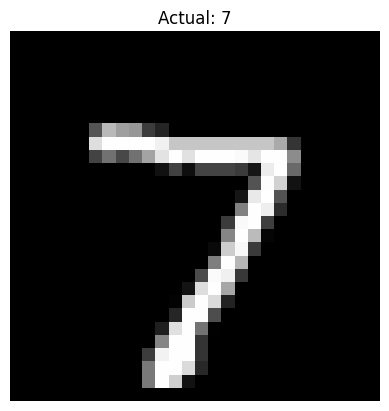

Predicted: 7


In [9]:
examples = iter(test_loader)
images, labels = next(examples)

plt.imshow(images[0][0], cmap="gray")
plt.title(f"Actual: {labels[0].item()}")
plt.axis("off")
plt.show()

with torch.no_grad():
    output = model(images[0].unsqueeze(0))
    _, predicted = torch.max(output, 1)
print(f"Predicted: {predicted.item()}")

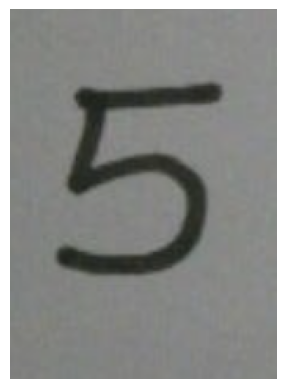

Predicted Digit: 5


In [11]:
from PIL import Image

model.load_state_dict(torch.load("cnn_mnist.pth")) if torch.cuda.is_available() else None
model.eval()

# Transform for uploaded image
custom_transform = transforms.Compose([
    transforms.Grayscale(),        # ensure single channel
    transforms.Resize((28, 28)),   # resize to MNIST size
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

def predict_image(image_path):
    img = Image.open(image_path)
    plt.imshow(img, cmap="gray")
    plt.axis("off")
    plt.show()

    img = custom_transform(img).unsqueeze(0)  # preprocess + batch dim
    with torch.no_grad():
        output = model(img)
        _, predicted = torch.max(output, 1)
    print(f"Predicted Digit: {predicted.item()}")


predict_image("/content/Screenshot 2025-09-11 at 9.06.07 PM.png")
